# MM-Net — data efficiency: is the ceiling the cohort or the model?

Staging on this corpus saturates around 0.72–0.75 across every model family we and others
have tried. Two explanations are usually offered and they have opposite consequences:

* **Model-limited** — a better architecture would break through, and the field should keep
  building models.
* **Data-limited** — 96 patients is the binding constraint, and the field should collect
  more patients rather than more parameters.

A learning curve distinguishes them. Train the identical model on a shrinking fraction of
the *training patients* while always evaluating on the full held-out fold. If performance
is still climbing at 100% of the data, the cohort is the constraint. If it has flattened,
more patients of this kind will not help and the limit is elsewhere.

Patients are subsampled, not epochs, because epochs within a patient are heavily
correlated — subsampling epochs would overstate how much independent data is available.

In [1]:
import json
import os
import sys
import time

import numpy as np
from sklearn.metrics import accuracy_score, cohen_kappa_score, f1_score, roc_auc_score

REPO = os.path.abspath(os.path.join(os.getcwd(), "..", "..", "..", ".."))
sys.path.insert(0, os.path.join(REPO, "MMNet_research", "model"))
import mmnet_core as C  # noqa: E402

OUT = os.path.join(REPO, "MMNet_research", "results", "revision", "runs")
os.makedirs(OUT, exist_ok=True)

FRACTIONS = [0.25, 0.50, 0.75, 1.00]
print("device:", C.DEV, "| patients:", len(C.SUBS), "| fractions:", FRACTIONS)

cwd: D:\sleep-staging-psg\MMNet_research\MMNet_Submission\all_codes\notebooks | device: cuda | NVIDIA GeForce RTX 2060


subjects: 96 (SN28 dropped) | epochs: 89,532
stage %: {'W': np.float64(26.6), 'N1': np.float64(10.2), 'N2': np.float64(42.3), 'N3': np.float64(8.9), 'R': np.float64(12.1)}
respiratory-event prevalence: 16.0%
EEG-feature counts -> EEG: 112 EOG: 50 EMG: 26
parameters (concat): 773,254
training utilities defined.
device: cuda | patients: 96 | fractions: [0.25, 0.5, 0.75, 1.0]


In [2]:
t0 = time.time()
curve = {}

for frac in FRACTIONS:
    per_fold = []
    for fi, (tr_all, te) in enumerate(C.FOLDS):
        rng = np.random.RandomState(100 + fi)
        tr_all = list(tr_all); rng.shuffle(tr_all)
        nv = max(10, len(tr_all) // 9)
        va, tr_full = tr_all[:nv], tr_all[nv:]

        # subsample training patients only; validation and test are untouched
        k = max(5, int(round(frac * len(tr_full))))
        sub = np.random.RandomState(500 + fi).permutation(len(tr_full))[:k]
        tr = [tr_full[i] for i in sorted(sub)]

        model = C.train_fold(tr, va, "concat", [], [], seed=42)

        # HMM transition matrix from the same reduced training set
        Am = np.ones((C.NC, C.NC)); pi = np.ones(C.NC)
        for s in tr:
            y = C.DATA[s][2]; pi[y[0]] += 1
            for x, z in zip(y[:-1], y[1:]): Am[x, z] += 1
        A_log = np.log(Am / Am.sum(1, keepdims=True)); pi_log = np.log(pi / pi.sum())

        yt, ph, ay, ap = [], [], [], []
        for s in te:
            sp, apn = C.subj_infer(model, s, [], [])
            y = C.DATA[s][2]
            yt.append(y); ph.append(C.hmm(A_log, pi_log, np.log(sp + C.EPS)))
            ay.append(C.DATA[s][3]); ap.append(apn)
        yt, ph = np.concatenate(yt), np.concatenate(ph)
        ay, ap = np.concatenate(ay), np.concatenate(ap)
        per_fold.append(dict(n_train=len(tr),
                             acc=float(accuracy_score(yt, ph)),
                             mf1=float(f1_score(yt, ph, average="macro", zero_division=0)),
                             kappa=float(cohen_kappa_score(yt, ph)),
                             auc=float(roc_auc_score(ay, ap))))
    curve[frac] = per_fold
    m = lambda k: (np.mean([f[k] for f in per_fold]), np.std([f[k] for f in per_fold]))
    print("frac %.2f  n_train %2d  acc %.4f +-%.3f  AUC %.4f +-%.3f   (%.1f min)"
          % (frac, per_fold[0]["n_train"], *m("acc"), *m("auc"), (time.time() - t0) / 60))

print("\ntotal %.1f min" % ((time.time() - t0) / 60))

frac 0.25  n_train 19  acc 0.6929 +-0.032  AUC 0.6556 +-0.051   (1.6 min)


frac 0.50  n_train 38  acc 0.7135 +-0.035  AUC 0.6852 +-0.045   (4.5 min)


frac 0.75  n_train 57  acc 0.7213 +-0.027  AUC 0.6957 +-0.034   (8.5 min)


frac 1.00  n_train 76  acc 0.7227 +-0.039  AUC 0.7111 +-0.034   (14.7 min)

total 14.7 min


## The curve, and what its shape implies

In [3]:
print("%-8s %8s %16s %16s %16s" % ("fraction", "patients", "accuracy", "macro-F1", "resp AUC"))
print("-" * 68)
for frac in FRACTIONS:
    pf = curve[frac]
    agg = lambda k: (np.mean([x[k] for x in pf]), np.std([x[k] for x in pf]))
    print("%-8.2f %8d %10.4f +-%.3f %10.4f +-%.3f %10.4f +-%.3f"
          % (frac, pf[0]["n_train"], *agg("acc"), *agg("mf1"), *agg("auc")))

acc = [np.mean([x["acc"] for x in curve[fr]]) for fr in FRACTIONS]
print()
print("marginal gain per added quartile of patients:")
for i in range(1, len(FRACTIONS)):
    print("  %.2f -> %.2f : %+.4f accuracy"
          % (FRACTIONS[i - 1], FRACTIONS[i], acc[i] - acc[i - 1]))

last = acc[-1] - acc[-2]
fold_sd = float(np.std([x["acc"] for x in curve[1.00]]))
verdict = "still rising" if last > 0.3 * fold_sd else "flat within noise"
print()
print("final step %+.4f accuracy; fold-to-fold sd %.4f  ->  %s" % (last, fold_sd, verdict))


fraction patients         accuracy         macro-F1         resp AUC
--------------------------------------------------------------------
0.25           19     0.6929 +-0.032     0.5944 +-0.043     0.6556 +-0.051
0.50           38     0.7135 +-0.035     0.6296 +-0.044     0.6852 +-0.045
0.75           57     0.7213 +-0.027     0.6465 +-0.036     0.6957 +-0.034
1.00           76     0.7227 +-0.039     0.6510 +-0.038     0.7111 +-0.034

marginal gain per added quartile of patients:
  0.25 -> 0.50 : +0.0206 accuracy
  0.50 -> 0.75 : +0.0078 accuracy
  0.75 -> 1.00 : +0.0014 accuracy

final step +0.0014 accuracy; fold-to-fold sd 0.0387  ->  flat within noise


wrote D:\sleep-staging-psg\MMNet_research\figures\fig_learning_curve.pdf
wrote D:\sleep-staging-psg\MMNet_research\figures\fig_learning_curve.png


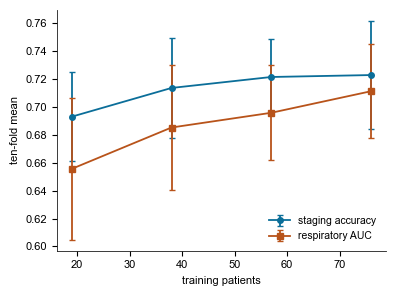

In [4]:
import matplotlib.pyplot as plt
%matplotlib inline

INK, ACCENT, SECOND = "#1a1a1a", "#0b6e99", "#b8531a"
plt.rcParams.update({"font.family": "sans-serif",
                     "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
                     "font.size": 8, "axes.linewidth": 0.6,
                     "axes.edgecolor": INK, "pdf.fonttype": 42})

n_pat = [curve[f][0]["n_train"] for f in FRACTIONS]
acc_m = [np.mean([x["acc"] for x in curve[f]]) for f in FRACTIONS]
acc_s = [np.std([x["acc"] for x in curve[f]]) for f in FRACTIONS]
auc_m = [np.mean([x["auc"] for x in curve[f]]) for f in FRACTIONS]
auc_s = [np.std([x["auc"] for x in curve[f]]) for f in FRACTIONS]

fig, ax = plt.subplots(figsize=(4.0, 3.0))
ax.errorbar(n_pat, acc_m, yerr=acc_s, marker="o", ms=4, lw=1.3,
            color=ACCENT, capsize=2, label="staging accuracy")
ax.errorbar(n_pat, auc_m, yerr=auc_s, marker="s", ms=4, lw=1.3,
            color=SECOND, capsize=2, label="respiratory AUC")
ax.set_xlabel("training patients")
ax.set_ylabel("ten-fold mean")
ax.legend(frameon=False, fontsize=7.5, loc="lower right")
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
fig.tight_layout()

FIGDIR = os.path.join(REPO, "MMNet_research", "figures")
for ext in ("pdf", "png"):
    p = os.path.join(FIGDIR, "fig_learning_curve." + ext)
    fig.savefig(p, dpi=300, bbox_inches="tight"); print("wrote", p)
plt.show()

json.dump({str(f): curve[f] for f in FRACTIONS},
          open(os.path.join(OUT, "data_efficiency.json"), "w"), indent=1)

## Reading the result

If the curve is still rising at the right-hand edge, the honest conclusion is that this
cohort — not this architecture — is what caps the reported accuracy, and the productive
next step for the field is more patients rather than more parameters. If it has flattened,
the opposite holds and our own "data-limited" framing would need to be withdrawn. Either
way the answer is measured rather than asserted.